In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df=pd.read_csv('Algerian_forest_fires_dataset_UPDATE.csv' ,header=1)

In [3]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.0+ KB


In [5]:
df.shape

(246, 14)

In [6]:
df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [7]:
df=df.dropna().reset_index(drop=True)
df

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,26,09,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire
240,27,09,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire
241,28,09,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire
242,29,09,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire


In [8]:
df.drop(['day', 'month', 'year'], axis=1, inplace=True)
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [9]:
df.columns

Index(['Temperature', ' RH', ' Ws', 'Rain ', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI',
       'FWI', 'Classes  '],
      dtype='object')

In [10]:
df.columns= df.columns.str.strip()

In [11]:
df.columns

Index(['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI',
       'FWI', 'Classes'],
      dtype='object')

In [12]:
df.iloc[[122]]

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes


In [13]:
df.shape

(244, 11)

In [14]:
df.drop(121,inplace=True)

In [15]:
df.iloc[[122]]

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
123,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire


In [16]:
df

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire
...,...,...,...,...,...,...,...,...,...,...,...
239,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire
240,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire
241,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire
242,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire


In [17]:
df.isnull().sum()

Temperature    0
RH             0
Ws             0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
dtype: int64

In [18]:
df.columns


Index(['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI',
       'FWI', 'Classes'],
      dtype='object')

In [19]:
df= df.reset_index(drop=True)

In [20]:
df

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire
...,...,...,...,...,...,...,...,...,...,...,...
238,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire
239,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire


In [24]:
df[df['Temperature']=='Temperature']

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
121,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes


In [28]:
df= df.drop(121).reset_index(drop=True)

In [30]:
df.shape

(242, 11)

In [29]:
df.iloc[121]

Temperature             32
RH                      71
Ws                      12
Rain                   0.7
FFMC                  57.1
DMC                    2.5
DC                     8.2
ISI                    0.6
BUI                    2.8
FWI                    0.2
Classes        not fire   
Name: 121, dtype: object

In [31]:
df[['Temperature', 'RH', 'Ws']]= df[['Temperature', 'RH', 'Ws']].astype(int)


In [32]:
df.columns

Index(['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI',
       'FWI', 'Classes'],
      dtype='object')

In [33]:
df[['FFMC', 'DMC', 'DC', 'ISI', 'BUI','FWI']] = df[['FFMC', 'DMC', 'DC', 'ISI', 'BUI','FWI']].astype(float)

In [35]:
df['Classes']= np.where(df['Classes'].str.contains("not fire"),0,1)
df

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0
4,27,77,16,0,64.8,3.0,14.2,1.2,3.9,0.5,0
...,...,...,...,...,...,...,...,...,...,...,...
237,30,65,14,0,85.4,16.0,44.5,4.5,16.9,6.5,1
238,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0
239,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0
240,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0


In [36]:
df['Classes'].value_counts()

Classes
1    137
0    105
Name: count, dtype: int64

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  242 non-null    int64  
 1   RH           242 non-null    int64  
 2   Ws           242 non-null    int64  
 3   Rain         242 non-null    object 
 4   FFMC         242 non-null    float64
 5   DMC          242 non-null    float64
 6   DC           242 non-null    float64
 7   ISI          242 non-null    float64
 8   BUI          242 non-null    float64
 9   FWI          242 non-null    float64
 10  Classes      242 non-null    object 
dtypes: float64(6), int64(3), object(2)
memory usage: 20.9+ KB


# Data visualizations


In [44]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


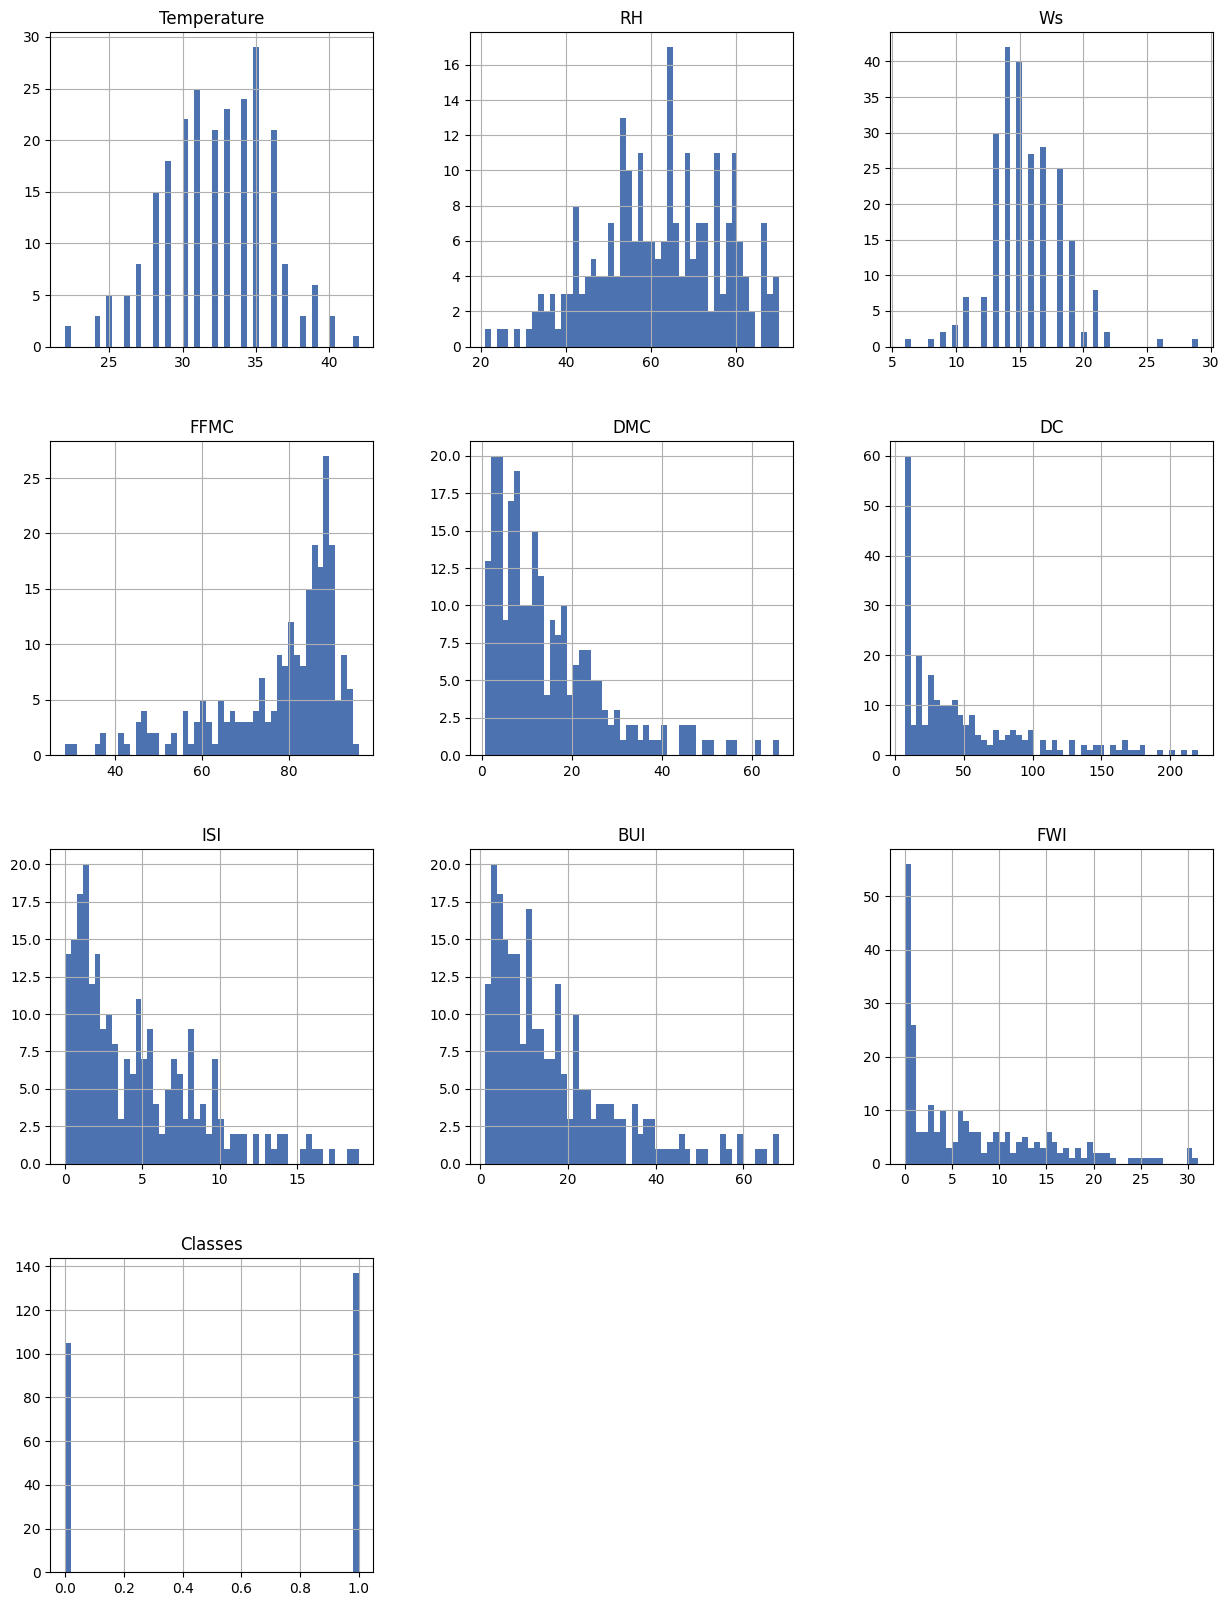

In [45]:

plt.style.use('seaborn-v0_8-deep')
df.hist(bins=50, figsize=(15,20))
plt.show()

#

<Axes: >

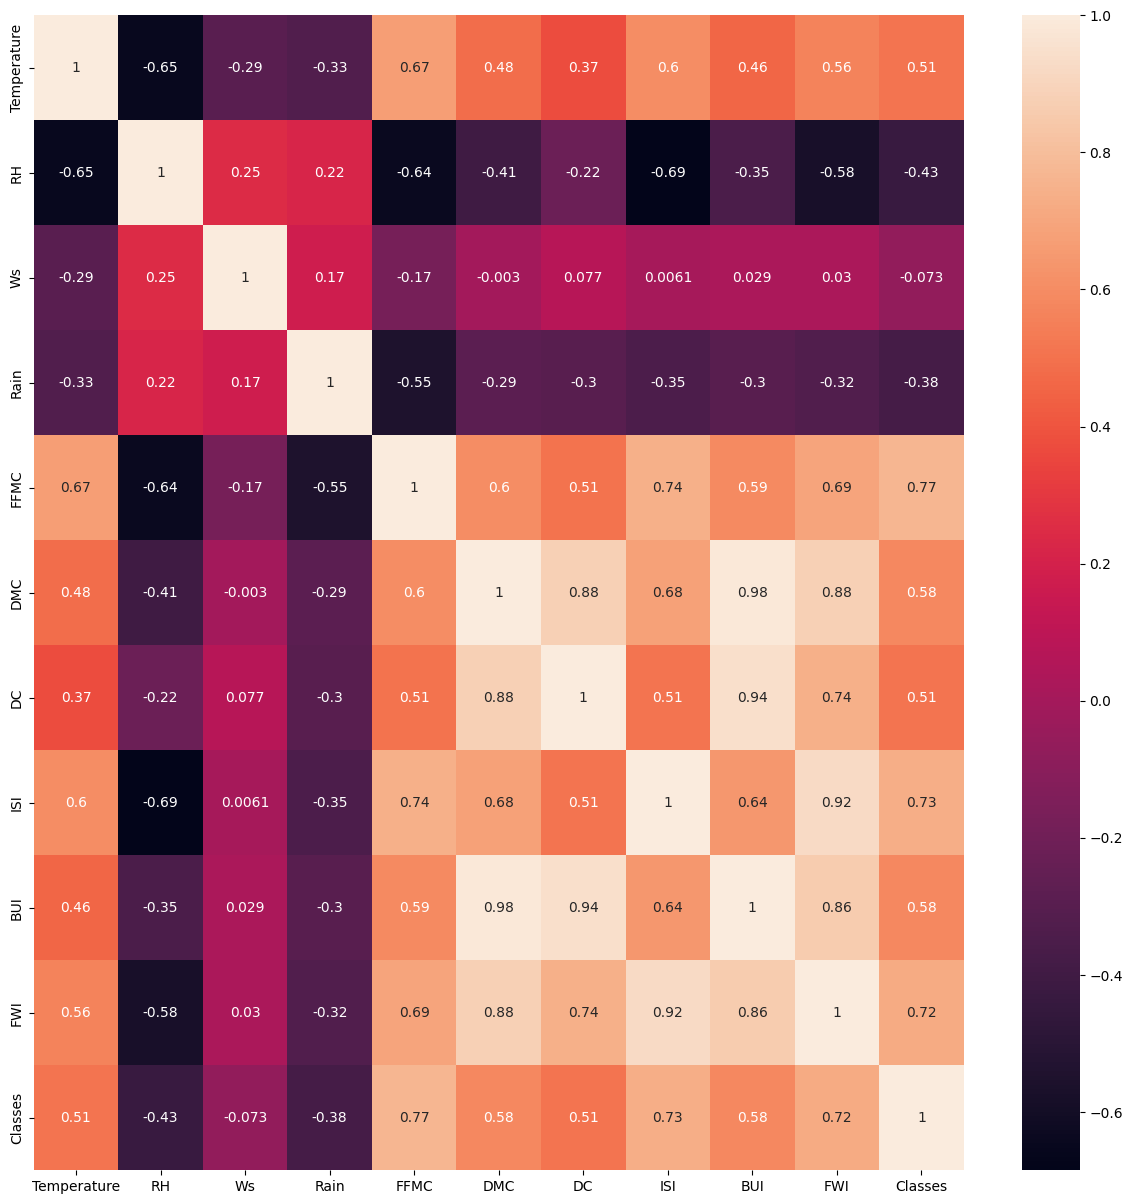

In [47]:
plt.figure(figsize=(15,15))
sns.heatmap(df.corr(), annot= True)

In [50]:

def corr(data, threshold):
    col_corr= set()
    corr_matrix= data.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                colname= corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

                

            
            
    

{'BUI', 'DC'}

In [53]:
x= df.drop(['FWI'], axis=1)
x

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes
0,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0
4,27,77,16,0,64.8,3.0,14.2,1.2,3.9,0
...,...,...,...,...,...,...,...,...,...,...
237,30,65,14,0,85.4,16.0,44.5,4.5,16.9,1
238,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0
239,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0
240,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0


In [39]:
y= df['FWI']
y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
237    6.5
238    0.0
239    0.2
240    0.7
241    0.5
Name: FWI, Length: 242, dtype: float64

In [55]:
corr_cols=corr(x, 0.85)
corr_cols

{'BUI', 'DC'}

In [56]:
x.drop(corr_cols, axis=1, inplace= True)

In [57]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test= train_test_split(x,y, test_size= 0.2, random_state= 52)
print(x_train.shape)
print(x_test.shape)

(193, 8)
(49, 8)


In [58]:
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()
x_train_scaled= scaler.fit_transform(x_train)
x_test_scaled= scaler.transform(x_test)
x_train_scaled

array([[-0.66591442, -0.19193495,  1.24354068, ...,  0.97967902,
         1.14312901,  0.84140632],
       [-0.09849065,  0.4707385 ,  0.18157895, ...,  0.01731039,
         0.12762616,  0.84140632],
       [ 0.46893311, -1.18594513, -1.23437002, ...,  0.77625151,
         1.47375785,  0.84140632],
       ...,
       [-0.66591442,  1.06714461,  1.59752792, ..., -0.83552035,
        -0.93510939, -1.18848643],
       [-1.80076195,  1.26594664,  1.24354068, ..., -0.11569991,
        -0.03768826,  0.84140632],
       [ 0.75264499, -1.31847982, -0.17240829, ...,  0.01731039,
        -0.15576999,  0.84140632]], shape=(193, 8))

In [60]:
from sklearn.linear_model import LinearRegression
reg= LinearRegression()
reg.fit(x_train_scaled, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [63]:
y_pred=reg.predict(x_test_scaled)
y_pred

array([13.4234401 ,  1.29072544, 14.14437316, 21.20733118,  0.81231202,
        1.8109807 , -0.47993945,  0.64730223, -0.11915079,  2.91983137,
       10.47385329, -0.85470194,  5.64819175,  0.16733202, 18.83662258,
        6.4451191 , -0.92397188,  7.39582865,  0.95713209, 13.11607802,
       14.02791275,  1.78000742, -0.23640805, -0.49686815, -0.33873612,
       13.92447768,  2.07995885,  4.4283193 ,  0.27948453, -0.63168191,
        4.15310849,  7.07837972,  6.18920097, -0.65361634,  6.72354226,
        7.07531998,  7.8894625 ,  0.82530855, 17.8356872 , -0.84717817,
       -0.74324674, 12.27109806, 15.11306914,  2.97447939,  3.9430651 ,
        0.20037366, 16.56765339, 11.32131173,  8.57018709])

# Metrics


MAE: 0.7362881153216689
MSE: 0.9170224960357477
R2_score: 0.9747411094488879


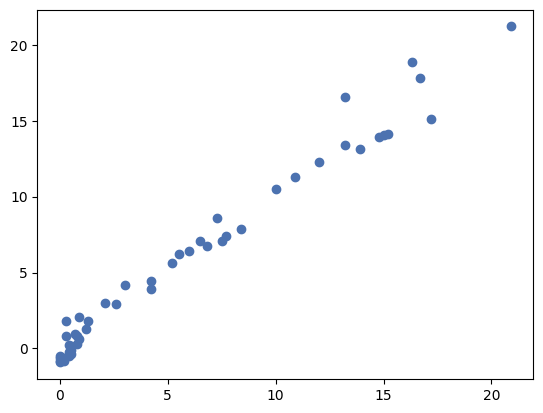

In [65]:
from sklearn.metrics import  mean_absolute_error, mean_squared_error,r2_score
mae= mean_absolute_error(y_test, y_pred)
mse= mean_squared_error(y_test, y_pred)
r2= r2_score(y_test, y_pred)


print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R2_score: {r2}")
plt.scatter(y_test,y_pred)

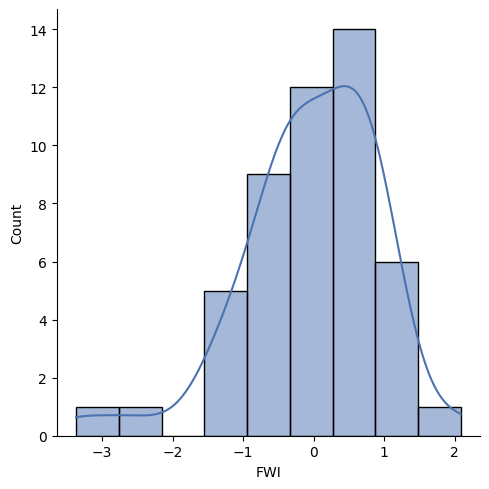

In [66]:
residuals= y_test - y_pred
sns.displot(residuals, kde= True)

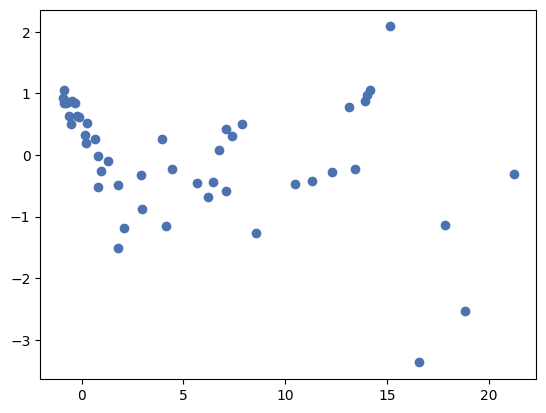

In [67]:
plt.scatter(y_pred, residuals)

# Export Model

In [68]:
import pickle
pickle.dump(reg, open("regressor.pkl", "wb"))

# Ridge and lasso Regressions


MAE: 0.7513892029984484
MSE: 0.9411588861335071
R2_score: 0.9740762855886077


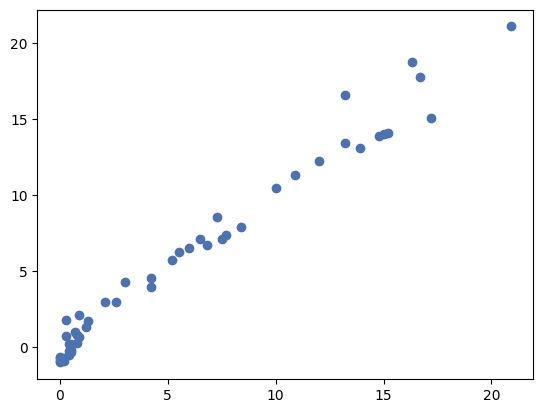

In [73]:
from sklearn.linear_model import Lasso, Ridge

ridge= Ridge()
ridge.fit(x_train_scaled, y_train)
y_pred= ridge.predict(x_test_scaled)
mae= mean_absolute_error(y_test, y_pred)
mse= mean_squared_error(y_test, y_pred)
r2= r2_score(y_test, y_pred)


print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R2_score: {r2}")
plt.scatter(y_test,y_pred)

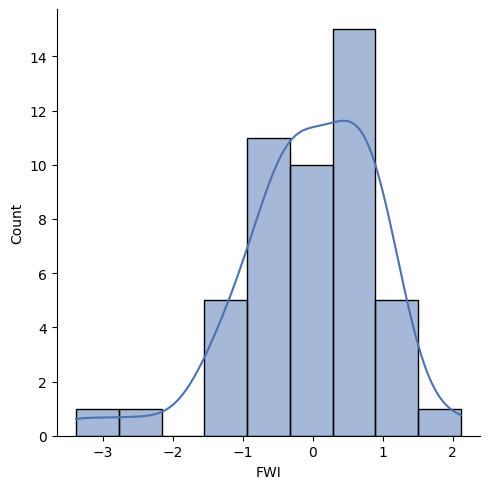

In [74]:
residuals= y_test - y_pred
sns.displot(residuals, kde= True)

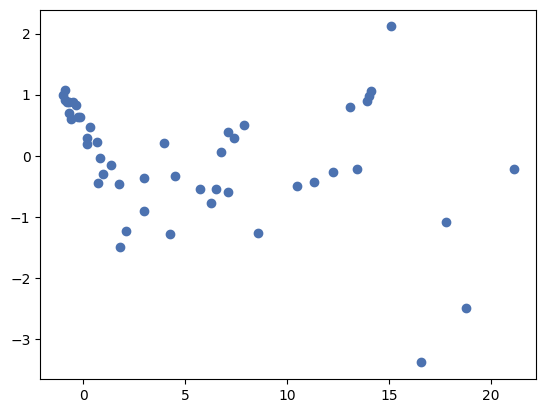

In [75]:
plt.scatter(y_pred, residuals)

In [76]:
pickle.dump(ridge, open("Ridge.pkl", 'wb'))


# LASSO REGRESSION

MAE: 0.9295454688222278
MSE: 1.281477735389869
R2_score: 0.9647023862535233


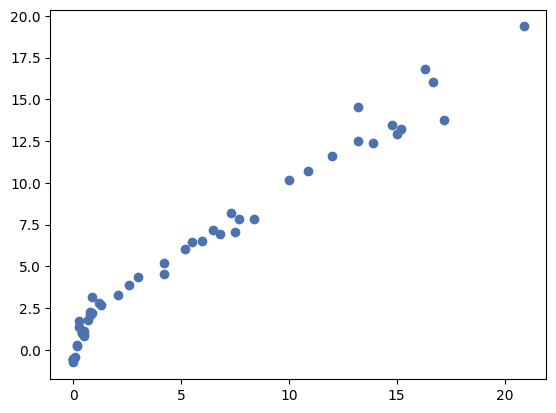

In [77]:
from sklearn.linear_model import Lasso, Ridge

lasso= Lasso()
lasso.fit(x_train_scaled, y_train)
y_pred= lasso.predict(x_test_scaled)
mae= mean_absolute_error(y_test, y_pred)
mse= mean_squared_error(y_test, y_pred)
r2= r2_score(y_test, y_pred)


print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R2_score: {r2}")
plt.scatter(y_test,y_pred)

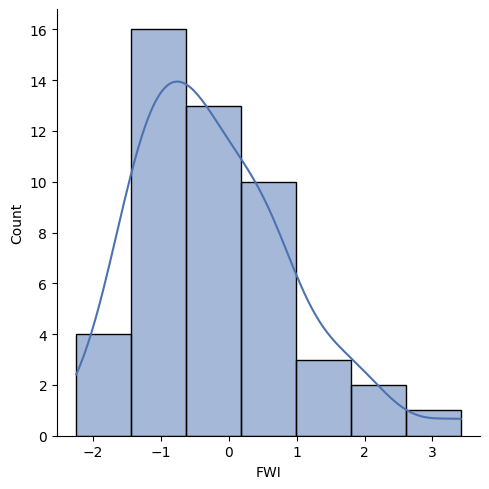

In [78]:
residuals= y_test - y_pred
sns.displot(residuals, kde= True)

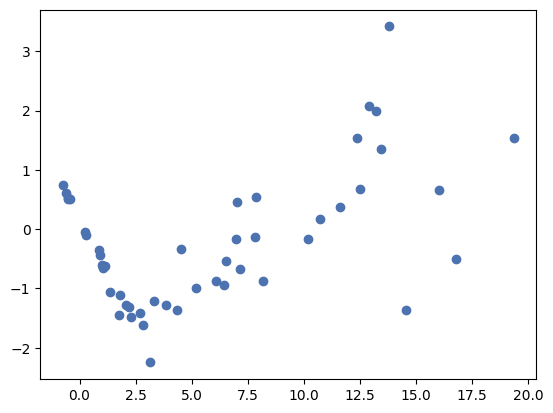

In [79]:
plt.scatter(y_pred, residuals)

In [80]:
pickle.dump(lasso, open("Lasso.pkl", 'wb'))


In [81]:
x_train.columns

Index(['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'ISI', 'Classes'], dtype='object')

In [82]:
pickle.dump(scaler, open("scaler.pkl", "wb"))